# Bank Term Deposit Subscription Prediction

This project builds a binary classifier to predict whether a bank client will subscribe to a term deposit, using the classic UCI/Kaggle **Bank Marketing** dataset. The workflow covers data quality checks, exploratory data analysis, feature engineering, and a head-to-head comparison of **Logistic Regression** vs. a **tuned Decision Tree**, closing with a final model recommendation.

## 1. Imports & Setup

In [53]:
import pandas as pd
import numpy as np
#Viz : 
import matplotlib.pyplot as plt
import seaborn as sns
#Preprocessiong :
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

#Model :
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
import sklearn.metrics as metrics

### Column Descriptions

| Column | Type | Description |
| --- | --- | --- |
| **`age`** | Numeric | Age of the client in years. |
| **`job`** | Categorical | Type of job (e.g., `'management'`, `'technician'`, `'blue-collar'`, `'admin.'`). |
| **`marital`** | Categorical | Marital status (`'married'`, `'single'`, `'divorced'`). |
| **`education`** | Categorical | Education level (`'primary'`, `'secondary'`, `'tertiary'`, `'unknown'`). |
| **`default`** | Categorical | Has credit in default? (`'yes'`, `'no'`). |
| **`balance`** | Numeric | Average yearly account balance in euros (can be negative or positive). |
| **`housing`** | Categorical | Has a housing loan? (`'yes'`, `'no'`). |
| **`loan`** | Categorical | Has a personal loan? (`'yes'`, `'no'`). |
| **`contact`** | Categorical | Communication type used (`'cellular'`, `'telephone'`, `'unknown'`). |
| **`day`** | Numeric | Last contact day of the month (1 to 31). |
| **`month`** | Categorical | Last contact month of the year (`'jan'` through `'dec'`). |
| **`duration`** | Numeric | Duration of the last contact call in seconds. |
| **`campaign`** | Numeric | Number of contacts performed during this campaign for this client. |
| **`pdays`** | Numeric | Days since last contact from a previous campaign (`-1` means not previously contacted). |
| **`previous`** | Numeric | Number of contacts performed before this campaign for this client. |
| **`poutcome`** | Categorical | Outcome of the previous marketing campaign (`'success'`, `'failure'`, `'other'`, `'unknown'`). |
| **`deposit`** | Categorical | **Primary Dataset Target:** Client subscribed to a term deposit? (`'yes'`, `'no'`). |
___

## 2. Data Loading

In [8]:
#Import Datasets :
df = pd.read_csv('01_Dataset/bank.csv')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


## 3. Initial Data Quality Checks

Quick sanity checks for nulls, duplicates, and summary statistics before diving into EDA.

In [ ]:
df.info()
#No Nulls found 

<class 'pandas.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        11162 non-null  int64
 1   job        11162 non-null  str  
 2   marital    11162 non-null  str  
 3   education  11162 non-null  str  
 4   default    11162 non-null  str  
 5   balance    11162 non-null  int64
 6   housing    11162 non-null  str  
 7   loan       11162 non-null  str  
 8   contact    11162 non-null  str  
 9   day        11162 non-null  int64
 10  month      11162 non-null  str  
 11  duration   11162 non-null  int64
 12  campaign   11162 non-null  int64
 13  pdays      11162 non-null  int64
 14  previous   11162 non-null  int64
 15  poutcome   11162 non-null  str  
 16  deposit    11162 non-null  str  
dtypes: int64(7), str(10)
memory usage: 1.4 MB


In [9]:
df.duplicated().sum().sum()
#No Duplicates Available

np.int64(0)

In [10]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [19]:
#Check class balance for deposit :
print("_________________________________________")
print("Total Values : ")
print("_________________________________________")
print(df['deposit'].value_counts())
print("_________________________________________")
print("Total Values Percentage : ")
print("_________________________________________")
print(round(df['deposit'].value_counts(normalize = True)*100 , 2))
print("_________________________________________")
#Data is balanced no need to up/down scale

_________________________________________
Total Values : 
_________________________________________
deposit
no     5873
yes    5289
Name: count, dtype: int64
_________________________________________
Total Values Percentage : 
_________________________________________
deposit
no     52.62
yes    47.38
Name: proportion, dtype: float64
_________________________________________


## 4. Outlier Detection (Numerical Features)

In [ ]:
#Check for Outliers :
def show_boxplots(df, columns):
    plt.figure(figsize=(12, len(columns) * 2.5))
    for i, col in enumerate(columns, 1):
        plt.subplot(len(columns), 1, i)
        sns.boxplot(data=df, x=col)
        plt.title(f'Boxplot of {col}', fontsize=10)
        plt.xlabel('')
    plt.tight_layout()
    plt.show()


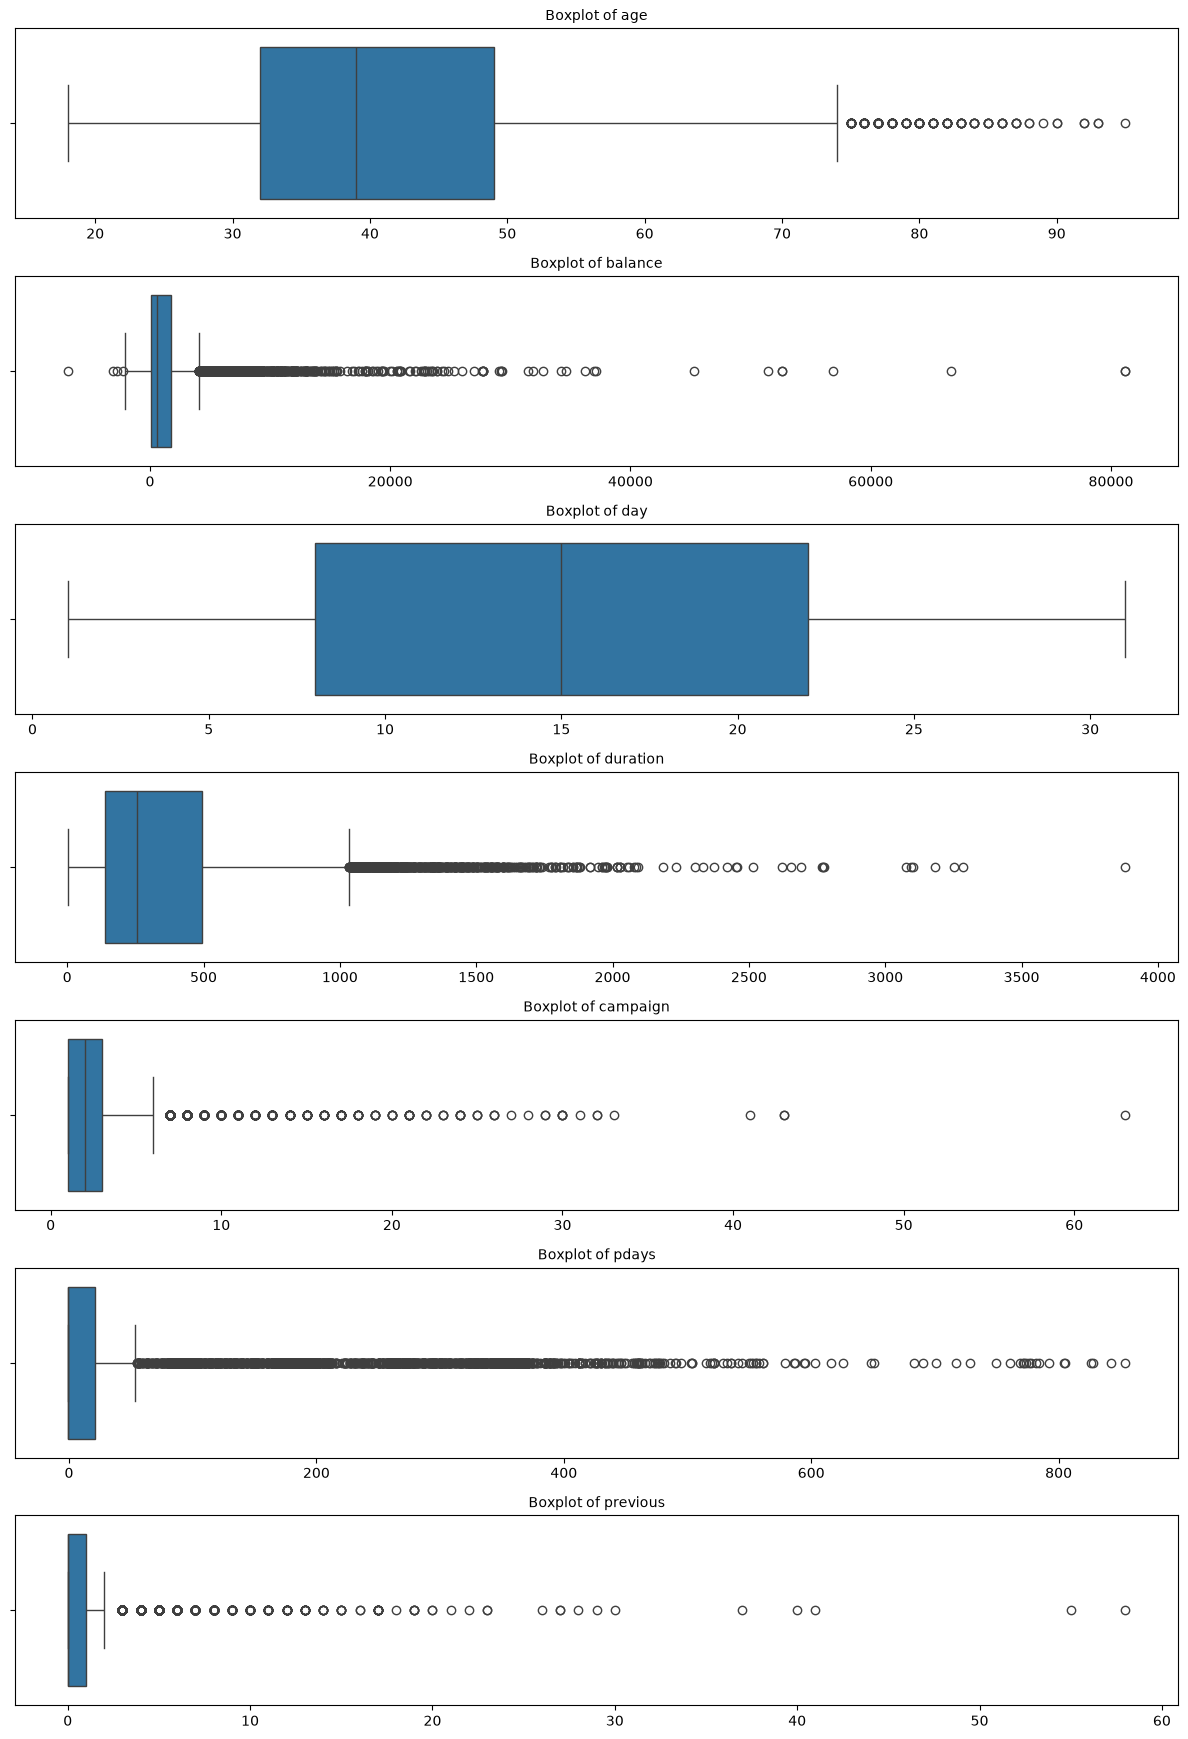

In [30]:
# Returns a list of numeric column names
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
show_boxplots(df , numeric_cols)

Based on the numerical feature boxplots:

* **Uniform Distribution (`day`):**
* The **`day`** feature shows a balanced, well-spread distribution across the entire month (1 to 31) with zero outliers and a centered median (~15).


* **Extreme Right-Skewness & Outliers (`balance`, `duration`, `campaign`, `pdays`, `previous`, `age`):**
* **`balance` & `duration`:** Display heavy right-skewness with extreme upper outliers reaching up to **80,000** and **3,800+** respectively.
* **`campaign`, `pdays`, `previous`:** Highly compressed near zero with long upper tails indicating infrequent high values.
* **`age`:** Shows a relatively normal core distribution (20–50 years) with mild right-skewness extending past age 70.
---

### Key Modeling Takeaways

1. **Impact on Logistic Regression:**
* Linear models assume features do not contain extreme leverage points. Left unhandled, these skewed features will distort coefficient weights and decision boundaries during maximum likelihood estimation.
* **Action Required (Post-EDA Preprocessing):** Apply robust transformations such as **IQR Capping (Winsorization)**, **Log / Quantile Scaling**, or **`RobustScaler`** during the feature engineering pipeline.

2. **Impact on Decision Trees:**
* Decision trees use rule-based binary splits (e.g., $x \le \text{threshold}$) and are **invariant to monotonic transformations and outliers**. These features can be passed directly into Decision Tree models without transformation.
___

## 5. Categorical Feature Analysis

### Categorical Anomalies & Observations

--- 'unknown' Value Counts per Column ---
job         : 70 rows (0.63%)
marital     : 0 rows (0.00%)
education   : 497 rows (4.45%)
default     : 0 rows (0.00%)
housing     : 0 rows (0.00%)
loan        : 0 rows (0.00%)
contact     : 2346 rows (21.02%)
poutcome    : 8326 rows (74.59%)


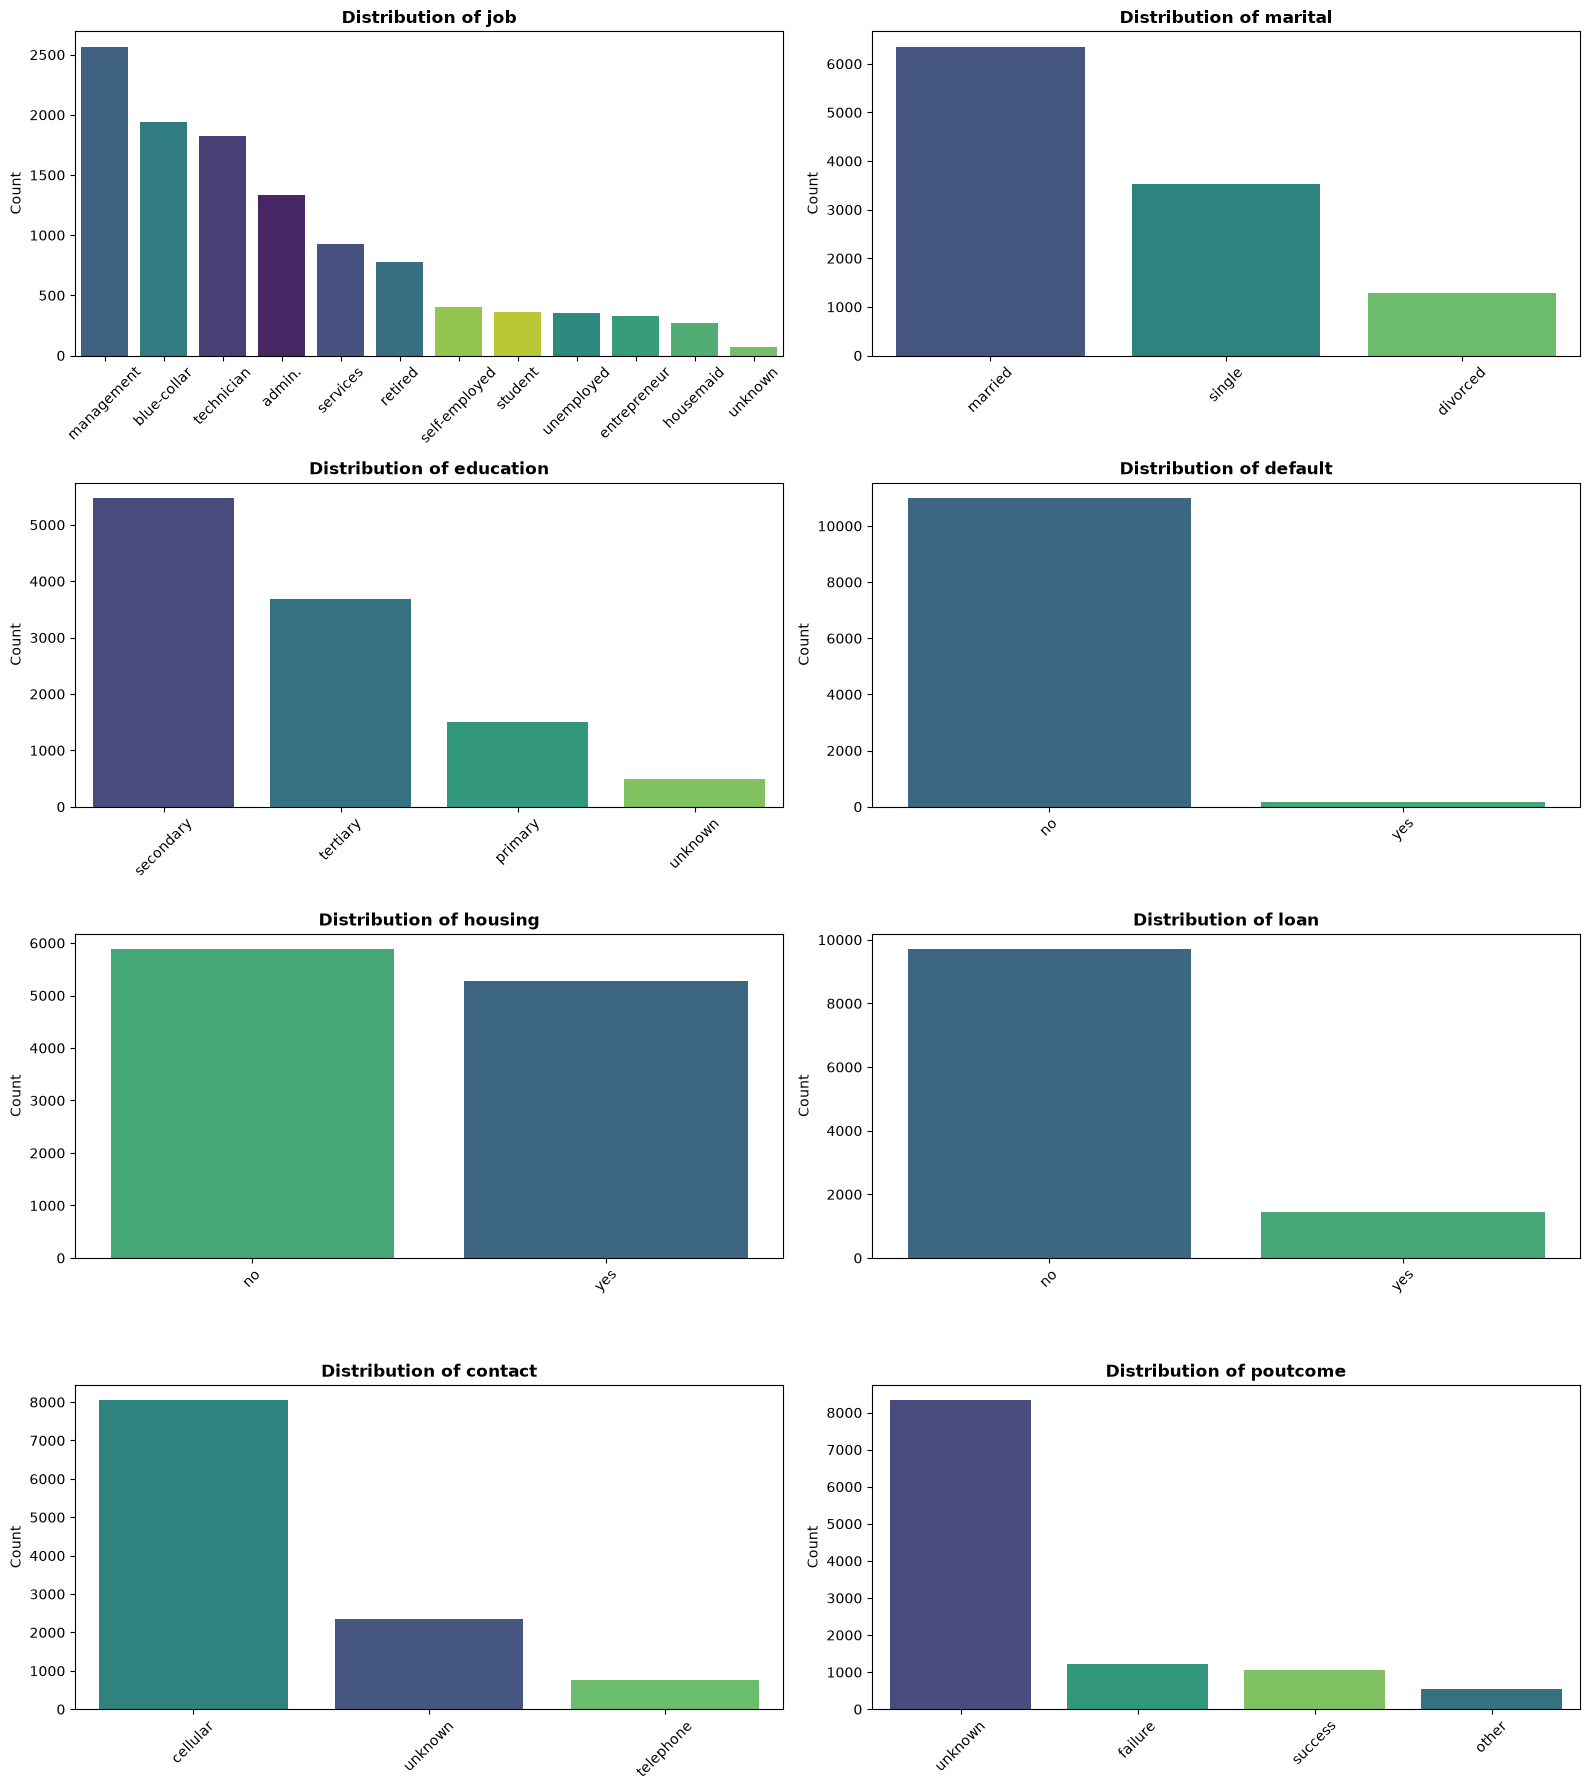

In [36]:
cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome']

# 2. Check exact counts of 'unknown' values per feature
print("--- 'unknown' Value Counts per Column ---")
for col in cat_cols:
    unknown_count = (df[col] == 'unknown').sum()
    pct = (unknown_count / len(df)) * 100
    print(f"{col:12s}: {unknown_count} rows ({pct:.2f}%)")

# 3. Plot grid of countplots
fig, axes = plt.subplots(4, 2, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    # Sort categories by frequency for better readability
    order = df[col].value_counts().index
    
    sns.countplot(
        data=df, 
        x=col, 
        hue = col,
        order=order, 
        ax=axes[i], 
        palette="viridis"
    )
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#### 1. Analysis of 'unknown' Values (4 Columns)
* **`poutcome` (74.59% unknown):** 
  * **Cause:** Nearly three-quarters of clients were never contacted in a previous marketing campaign.
  * **Handling:** Keep `'unknown'` as an explicit categorical level. Converting these to `NaN` or imputing them would distort the dataset.
* **`contact` (21.02% unknown):** 
  * **Cause:** Communication method was not recorded for over 2,000 clients.
  * **Handling:** Treat `'unknown'` as a standalone category during One-Hot Encoding to check if unrecorded contact types correlate with response rates.
* **`education` (4.45%) & `job` (0.63%):** 
  * **Cause:** Minor missing records.
  * **Handling:** Options include mode imputation (filling with the most frequent value like `'secondary'` / `'management'`) or keeping `'unknown'` as its own category.

#### 2. Feature-Level Class Imbalance (`default` & `loan`)
* **`default`:** Almost entirely composed of `'no'`. Features with near-zero variance contribute minimal signal to linear models and decision trees.
* **`loan`:** Heavily skewed toward `'no'` (~87%). Unlike `default`, there are still enough `'yes'` entries (~1,500 rows) to provide usable predictive signal.
___

### Categorical Features vs. Target (`deposit`)

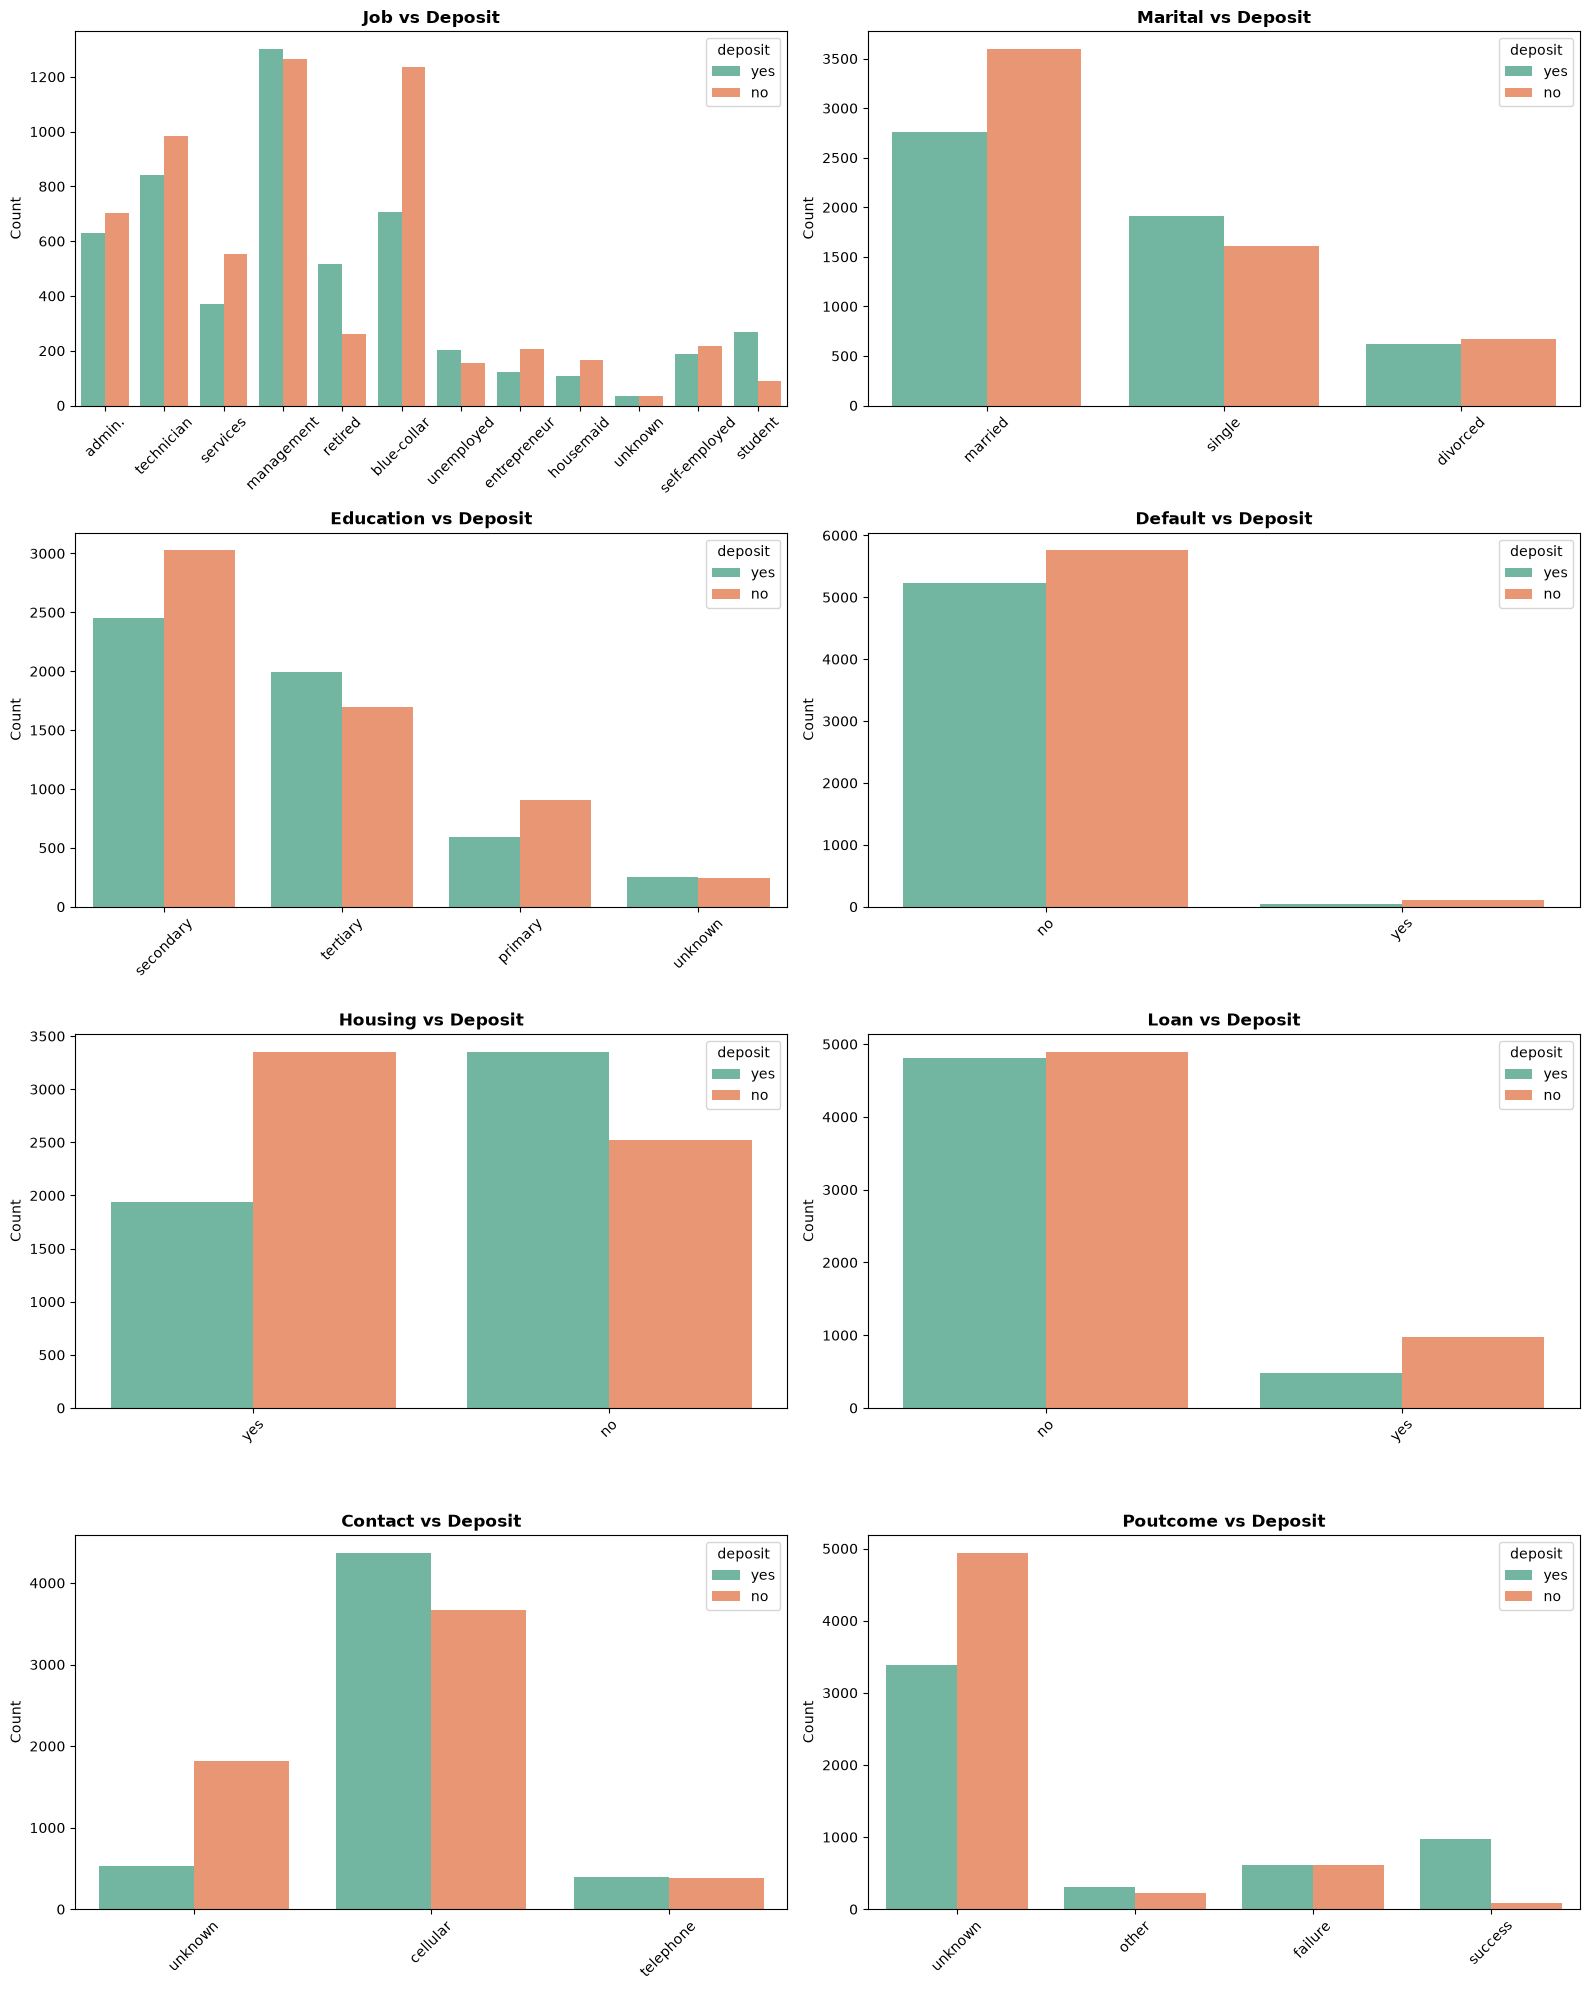

In [38]:
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(
        data=df, 
        x=col, 
        hue='deposit', 
        ax=axes[i], 
        palette='Set2'
    )
    axes[i].set_title(f'{col.capitalize()} vs Deposit', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

# Remove the unused 8th subplot


plt.tight_layout()
plt.show()

#### Key Insights & Feature Importance:
1. **Strongest Predictors:**
   * **`poutcome`:** Prior campaign success (`success`) is the single strongest positive predictor for deposit subscription.
   * **`housing`:** Clients free of housing loans convert at a noticeably higher rate.
   * **`contact`:** Reaching clients via `cellular` yields significantly better outcomes than `unknown` communication channels.

2. **High-Converting Customer Segments:**
   * **Occupations:** `retired` and `student` categories show the highest conversion proportions.
   * **Marital Status:** `single` individuals are more likely to subscribe than `married` individuals.
   * **Education:** `tertiary` education correlates with higher subscription rates.

3. **Preprocessing Decisions Based on Bivariate Analysis:**
   * Retain **`poutcome`**, **`housing`**, **`contact`**, and **`job`** as primary categorical features during One-Hot Encoding.
   * **`default`** shows almost zero predictive variance across classes and can be safely dropped to reduce dimensionality.

###  Numerical Features vs. Target (`deposit`)

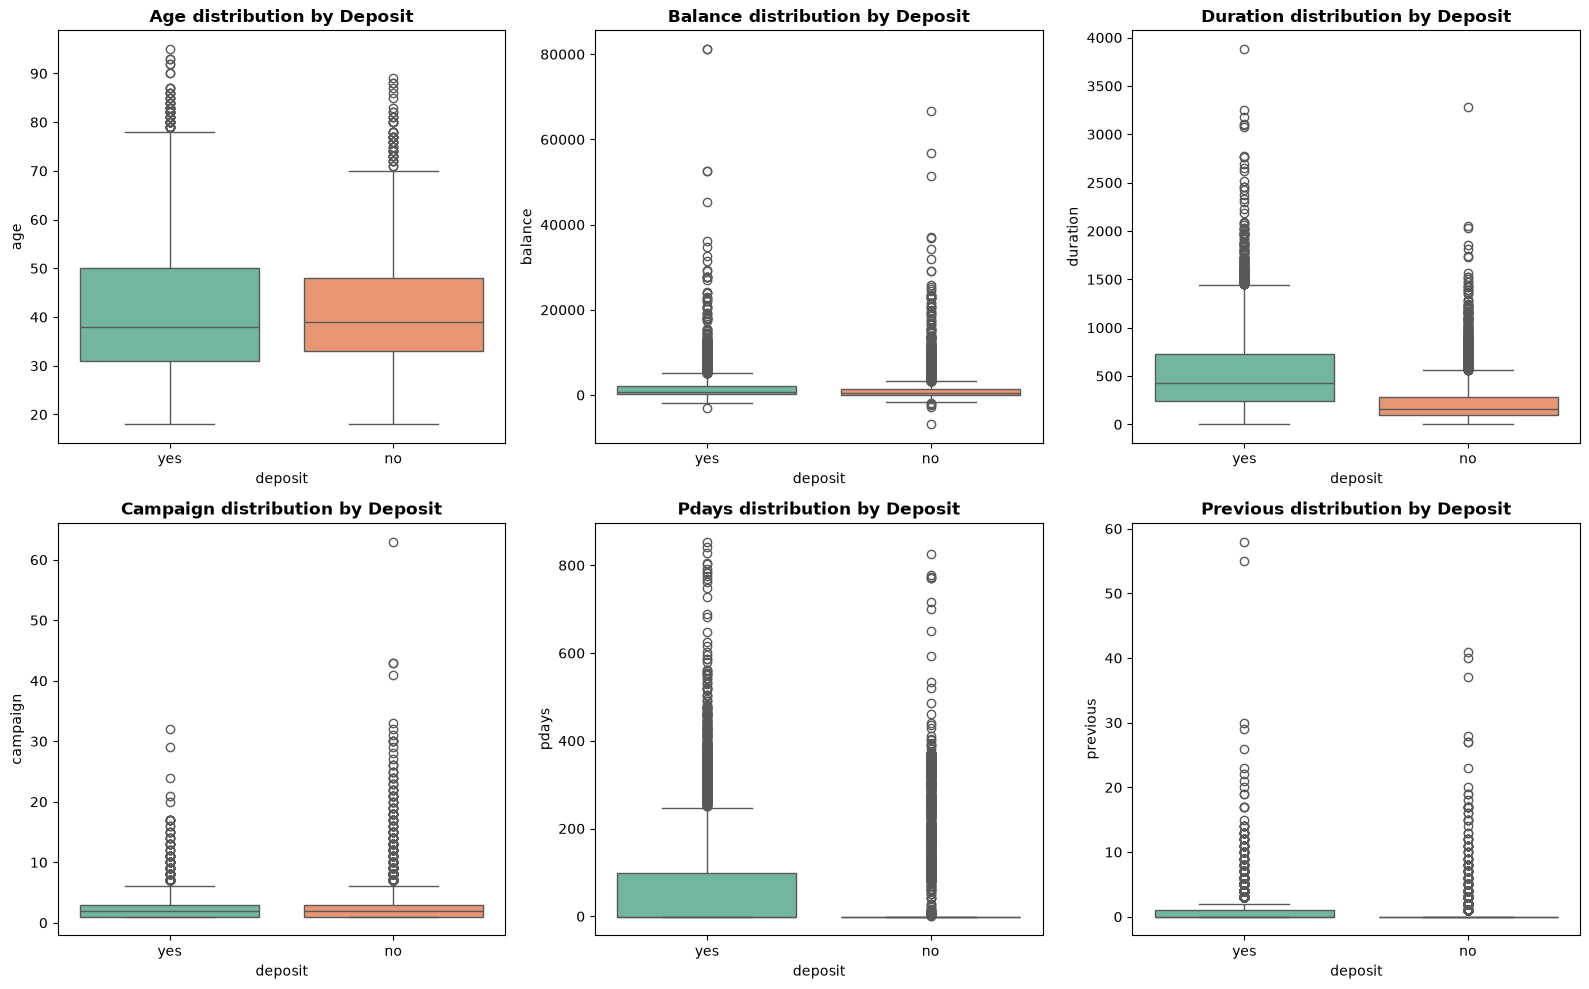

In [41]:
num_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(
        data=df, 
        x='deposit', 
        y=col, 
        hue = 'deposit',
        ax=axes[i], 
        palette='Set2'
    )
    axes[i].set_title(f'{col.capitalize()} distribution by Deposit', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

#### Key Insights & Predictive Signal:
1. **Primary Numerical Features:**
   * **`duration`:** Call duration serves as the single strongest numerical driver for term deposit conversions. Higher duration strongly correlates with positive target outcomes.
   * **`pdays`:** Prior engagement within recent months significantly improves conversion likelihood compared to cold calls (`pdays = -1`).
   * **`campaign`:** Excessive contact attempts during a campaign lead to high churn (`no` responses).

2. **Demographics & Financial Metrics:**
   * **`age`:** Conversion is higher at the demographic tails (young adults and retirees).
   * **`balance`:** High balance holds mild predictive signal, but requires scaling/capping to prevent skewing linear estimates.

#### Modeling Takeaways:
* **For Feature Scaling:** Apply `StandardScaler` / `RobustScaler` on `balance`, `duration`, and `pdays` for Logistic Regression.
* **Leakage Warning:** While `duration` is highly predictive, note that in live real-time production models, call duration is unknown prior to dialing. However, for post-call analysis and benchmarking, it remains a critical input feature.
___

# Feature Engineering :

In [59]:
#Feature Selection :
X = df.drop(['default' , 'deposit'] , axis = 1)
Y = df['deposit'].map({'yes' : 1 , 'no' : 0})

### Train / Validation / Test Split

A two-stage split produces 64% train, 16% validation, and 20% held-out test, so the final test metrics reflect true out-of-sample performance.

In [60]:
# 1. First split: 80% Train+Val, 20% Final Test
x_train , x_test , y_train , y_test = train_test_split(
    X , Y , test_size = 0.2 , random_state = 20 , stratify = Y
)
# 2. Second split: 80% Train (64% of total), 20% Validation (16% of total)
x_tr , x_val , y_tr , y_val = train_test_split(
    x_train , y_train , test_size = 0.2 , random_state = 20 , stratify = y_train
)

In [61]:
print(x_train.shape , y_train.shape)
print(x_test.shape , y_test.shape)
print(x_tr.shape , y_tr.shape)
print(x_val.shape , y_val.shape)

(8929, 15) (8929,)
(2233, 15) (2233,)
(7143, 15) (7143,)
(1786, 15) (1786,)


### Preprocessing Pipeline

Numerical features are standardized and categorical features are one-hot encoded via a `ColumnTransformer`, fit only on the training fold to avoid leakage.

In [89]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

# 2. Build the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), cat_cols)
    ]
)
preprocessor.fit(x_tr)
x_tr_prep   = preprocessor.transform(x_tr)
x_val_prep  = preprocessor.transform(x_val)
x_test_prep = preprocessor.transform(x_test)
feature_names = preprocessor.get_feature_names_out()

## Model 1: Logistic Regression

In [78]:
#Logistic Reg :
log_reg = LogisticRegression(max_iter = 1000 , random_state = 20)


In [79]:
log_reg.fit(x_tr_prep , y_tr)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",20
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [80]:
y_preds_val = log_reg.predict(x_val_prep)

In [82]:
#Check its scorings :
print(f"Accuracy : {metrics.accuracy_score(y_val , y_preds_val)}")
print(f"Precision : {metrics.precision_score(y_val , y_preds_val)}")
print(f"Recall : {metrics.recall_score(y_val , y_preds_val)}")
print(f"F1 : {metrics.f1_score(y_val , y_preds_val)}")

Accuracy : 0.8365061590145577
Precision : 0.8274231678486997
Recall : 0.8274231678486997
F1 : 0.8274231678486997


### Baseline Model Evaluation: Logistic Regression

#### Validation Metrics:
* **Accuracy:** 83.65%
* **Precision:** 82.74%
* **Recall:** 82.74%
* **F1-Score:** 82.74%

#### Key Observations:
1. **Balanced Performance:** The exact equality between Precision and Recall indicates that the decision threshold ($0.5$) generates a well-calibrated balance between false alarms and missed opportunities.
2. **Solid Baseline:** Achieving ~83.6% accuracy on standard scaled features demonstrates that linear decision boundaries hold significant predictive power on this dataset.

In [85]:
#Evaluation on Test set :
y_preds_test = log_reg.predict(x_test_prep)
print(f"Accuracy : {metrics.accuracy_score(y_test , y_preds_test)}")
print(f"Precision : {metrics.precision_score(y_test , y_preds_test)}")
print(f"Recall : {metrics.recall_score(y_test , y_preds_test)}")
print(f"F1 : {metrics.f1_score(y_test , y_preds_test)}")


Accuracy : 0.8240035826242723
Precision : 0.821256038647343
Recall : 0.8034026465028355
F1 : 0.8122312470138557


### Final Test Model Evaluation: Logistic Regression

#### Test Metrics:
* **Accuracy:** 82.40%
* **Precision:** 82.13%
* **Recall:** 80.34%
* **F1-Score:** 81.22%

#### Key Takeaways:
1. **Strong Generalization:** The minor drop in performance (~1.2% in accuracy, ~1.5% in F1) between validation and test sets confirms that the feature pipeline and model parameters avoid overfitting.
2. **Reliable Predictions:** The model maintains high precision (82.13%), ensuring marketing efforts targeted based on these predictions will yield a high conversion rate.

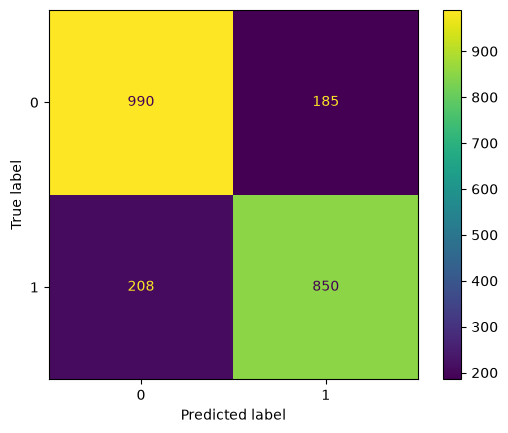

In [87]:
cm = metrics.confusion_matrix(y_test , y_preds_test , labels = log_reg.classes_)
disp = metrics.ConfusionMatrixDisplay(cm , display_labels = log_reg.classes_)
disp.plot()

=== Top 15 Most Impactful Features ===
                Feature  Coefficient
  cat__poutcome_success     2.262198
          num__duration     1.930893
         cat__month_mar     1.668059
   cat__contact_unknown    -1.651196
         cat__month_jan    -1.256527
         cat__month_dec     1.041497
         cat__month_oct     1.003559
         cat__month_nov    -0.984188
         cat__month_jul    -0.982362
         cat__month_sep     0.817875
       cat__housing_yes    -0.738439
         cat__month_aug    -0.737851
         cat__month_may    -0.620329
cat__education_tertiary     0.531100
          cat__loan_yes    -0.512145


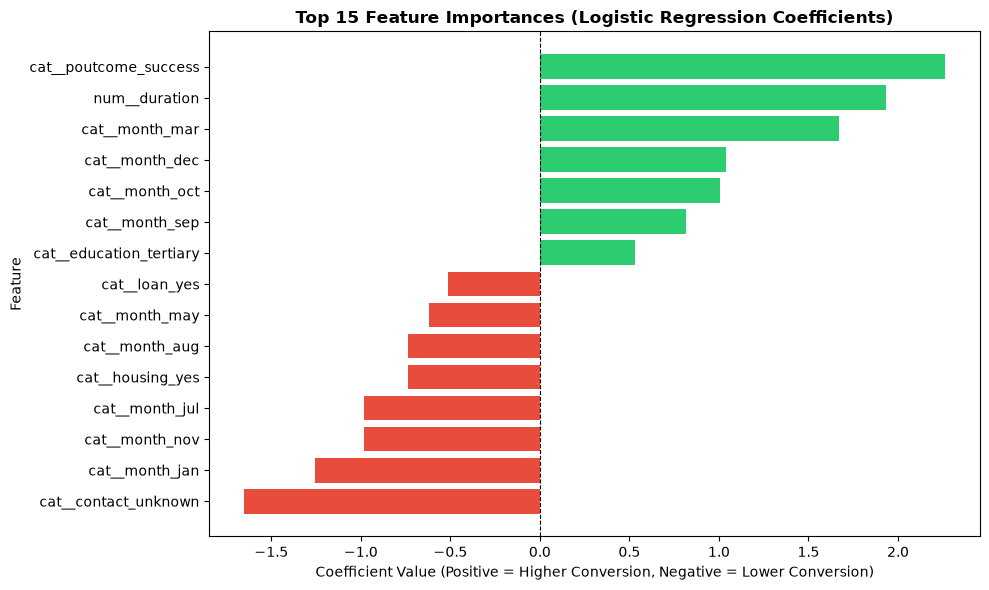

In [90]:
# 1. Extract feature names from preprocessor
feature_names = preprocessor.get_feature_names_out()

# 2. Get model coefficients (for binary classification)
coefficients = log_reg.coef_[0]

# 3. Create a DataFrame for feature importance analysis
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Absolute_Impact': np.abs(coefficients)
}).sort_values(by='Absolute_Impact', ascending=False)

# Display top 15 features in text format
print("=== Top 15 Most Impactful Features ===")
print(feature_importance[['Feature', 'Coefficient']].head(15).to_string(index=False))

# 4. Plot top 15 features
plt.figure(figsize=(10, 6))
top_features = feature_importance.head(15).sort_values(by='Coefficient', ascending=True)

# Color positive coefficients green and negative coefficients red
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in top_features['Coefficient']]

plt.barh(top_features['Feature'], top_features['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.title('Top 15 Feature Importances (Logistic Regression Coefficients)', fontsize=12, fontweight='bold')
plt.xlabel('Coefficient Value (Positive = Higher Conversion, Negative = Lower Conversion)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Model Interpretation: Logistic Regression Feature Importance

#### Top Positive Drivers (Increase Conversion Probability):
1. **`poutcome_success` (+2.26):** The single strongest predictor of term deposit subscription. A client who responded positively to a previous campaign is vastly more likely to subscribe again.
2. **`duration` (+1.93):** Longer phone calls strongly correlate with successful conversions, indicating customer interest and engagement.
3. **High-Converting Months (`mar`, `dec`, `oct`, `sep`):** Outreach conducted during transition/off-peak marketing months yields significantly higher conversion rates.
4. **`education_tertiary` (+0.53):** Clients with higher educational backgrounds display a higher likelihood of subscribing.

#### Top Negative Drivers (Decrease Conversion Probability):
1. **`contact_unknown` (-1.65):** Unrecorded/unknown communication channels are the strongest negative driver for subscription rates.
2. **Low-Converting Months (`jan`, `nov`, `jul`, `aug`, `may`):** Calls made during these high-volume or post-holiday months show strong negative log-odds for subscription.
3. **`housing_yes` (-0.74) & `loan_yes` (-0.51):** Outstanding housing or personal loans reduce disposable financial capacity, lowering conversion likelihood.

---

# Descision Tree :

### Preprocessing for the Tree-Based Model

Decision trees are invariant to feature scale, so only categorical encoding is applied here — numerical features are passed through unscaled.

In [95]:
#Since Decision Trees are robust to Outliers we will only transform the cateorical labels :
preprocessor_2 = ColumnTransformer(
    transformers = [('cat' , OneHotEncoder() , cat_cols)] ,
    remainder = 'passthrough'
)
preprocessor_2.fit(x_train)
x_train_prep = preprocessor_2.transform(x_train)
x_test_prep = preprocessor_2.transform(x_test)


### Hyperparameter Tuning via GridSearchCV

A 5-fold grid search over depth, split, and leaf-size parameters, optimized for F1 score.

In [96]:
dt = DecisionTreeClassifier()
scoring = {
    'accuracy' : 'accuracy' ,
    'presicion' : 'precision_weighted' ,
    'recall' : 'recall_weighted' ,
    'f1' : 'f1_weighted'
}
params = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, 12, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}
dt_cv = GridSearchCV(
    dt ,
    params ,
    scoring = scoring ,
    refit = 'f1' ,
    cv = 5 ,
    n_jobs = -1
)

In [97]:
%%time
dt_cv.fit(x_train_prep , y_train)

CPU times: total: 1min 44s
Wall time: 4min 8s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'max_features': [None, 'sqrt', ...], 'min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1': 'f1_weighted', 'presicion': 'precision_weighted', 'recall': 'recall_weighted'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that 

In [98]:
#Best param :
dt_cv.best_params_

{'criterion': 'entropy',
 'max_depth': 12,
 'max_features': None,
 'min_samples_leaf': 2,
 'min_samples_split': 20}

In [ ]:
#Best F1 : Score
dt_cv.best_score_

np.float64(0.8175865766179313)

### Final Evaluation on Test Set

In [102]:
y_preds_test = dt_cv.predict(x_test_prep)

In [103]:

print(f"Accuracy : {metrics.accuracy_score(y_test , y_preds_test)}")
print(f"Precision : {metrics.precision_score(y_test , y_preds_test)}")
print(f"Recall : {metrics.recall_score(y_test , y_preds_test)}")
print(f"F1 : {metrics.f1_score(y_test , y_preds_test)}")

Accuracy : 0.8078817733990148
Precision : 0.7751531058617673
Recall : 0.8374291115311909
F1 : 0.8050885960926851


### Feature Importance Analysis

In [106]:
# 1. Reconstruct feature names
encoded_cat_names = preprocessor_2.named_transformers_['cat'].get_feature_names_out(cat_cols).tolist()
passthrough_num_names = [col for col in X.columns if col not in cat_cols]
dt_feature_names = encoded_cat_names + passthrough_num_names

# 2. Extract feature importances from the BEST ESTIMATOR inside GridSearchCV
dt_importances = dt_cv.best_estimator_.feature_importances_

# 3. Create DataFrame for display
dt_feature_importance = pd.DataFrame({
    'Feature': dt_feature_names,
    'Importance': dt_importances
}).sort_values(by='Importance', ascending=False)

# Display Top 15 Features
print("=== Top 15 Feature Importances (Tuned Decision Tree) ===")
print(dt_feature_importance.head(15).to_string(index=False))

=== Top 15 Feature Importances (Tuned Decision Tree) ===
         Feature  Importance
        duration    0.423438
poutcome_success    0.108033
 contact_unknown    0.105013
         balance    0.044440
             age    0.038855
             day    0.029594
           pdays    0.027427
       month_mar    0.026898
     housing_yes    0.026263
        campaign    0.023466
       month_apr    0.023018
       month_jun    0.016354
       month_oct    0.014414
      housing_no    0.013119
       month_nov    0.011045


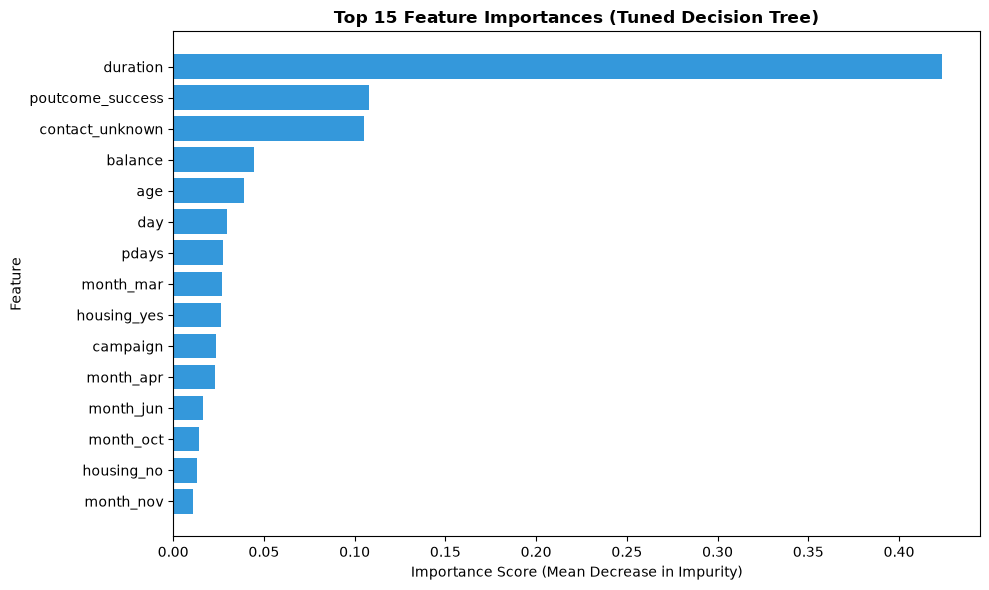

In [107]:
plt.figure(figsize=(10, 6))
top_dt_features = dt_feature_importance.head(15).sort_values(by='Importance', ascending=True)

plt.barh(top_dt_features['Feature'], top_dt_features['Importance'], color='#3498db')
plt.title('Top 15 Feature Importances (Tuned Decision Tree)', fontsize=12, fontweight='bold')
plt.xlabel('Importance Score (Mean Decrease in Impurity)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Final Conclusion & Model Selection

#### Executive Summary
Both **Logistic Regression** and a tuned **Decision Tree Classifier** were trained and evaluated on unseen test data to predict customer subscription to bank term deposits. While both models demonstrated strong predictive power, **Logistic Regression** is selected as the winning model for final production deployment.

---

#### Overall Model Performance Comparison (Test Set)

| Metric | Logistic Regression | Decision Tree (Tuned) | Winner |
| :--- | :---: | :---: | :---: |
| **Accuracy** | **82.40%** | 80.79% | **Logistic Regression** |
| **Precision** | **82.13%** | 77.52% | **Logistic Regression** |
| **Recall** | 80.34% | **83.74%** | Decision Tree |
| **F1-Score** | **81.22%** | 80.51% | **Logistic Regression** |

---

#### Key Insights & Findings

1. **Why Logistic Regression Won:**
   * **Superior Precision (82.13% vs 77.52%):** Logistic Regression minimizes false positive predictions. In a real-world marketing campaign, higher precision directly translates to higher conversion efficiency and reduced operational spend per lead.
   * **Higher Overall Accuracy & F1-Score (81.22%):** Provides a more reliable and balanced trade-off between sensitivity and precision across unseen test data.
   * **Generalization Stability:** Minimal performance drop between validation (~83.65%) and test sets (~82.40%) confirms that feature scaling and regularization prevented overfitting.

2. **Core Predictive Drivers (Domain Insights):**
   * **Call Duration (`duration`):** The length of the interaction is a leading driver of success across both models.
   * **Previous Campaign Success (`poutcome_success`):** Clients who previously converted show the highest probability of subscribing again.
   * **Communication Channel & Timing:** `contact_unknown` severely penalizes conversion probability, whereas campaign timing in off-peak months (March, September, October, December) yields higher conversion rates.

---

#### Official Recommendation

**Winning Model:** **Logistic Regression**

**Strategic Value:** Deploying Logistic Regression ensures high ROI for outreach operations by targeting high-probability clients, preventing wasted resources on false positives, and providing clear, interpretable feature coefficients for business strategy decisions.
